# B · From default probability to credit loss

## Lecture 10: LGD, EAD and model-based expected principal loss

Notebook A asked **how likely is default?** This notebook asks **how much would the lender lose if default occurs?** We combine probability of default (PD), loss given default (LGD), and exposure at default (EAD) to estimate losses in dollars.

$$
\widehat{EL}_i=\widehat{PD}_i\times\widehat{LGD}_i\times\widehat{EAD}_i.
$$

Our central lesson is **define → measure → predict → evaluate → interpret**. We start with historical averages, then ask whether simple regression models improve on them. More code does not guarantee a better forecast.


## Before you start

### What you will learn

By the end, you should be able to:

1. distinguish PD, conditional LGD, conditional EAD and expected loss;
2. construct and explain severity proxies from repayment and recovery records;
3. estimate conditional means with a simple fractional-logit model;
4. compare forecasts with development-sample averages;
5. combine forecasts into loan and portfolio loss estimates; and
6. Distinguish expected and realised credit losses, and explain how stress scenarios could affect expected loss.

### Files and Python environment

Keep this notebook, requirements.txt, and the data and outputs folders together in the Lecture 10 folder. The notebook uses:

- data/credit_risk_course_data.csv — the original course loan data.
- outputs/pd_test_predictions.csv — the out-of-vintage PD predictions for the 2012 cohort produced by Notebook A.

Use Python 3.12 and select your course Python environment in Jupyter or VS Code.

If the required packages are not installed, run the following command once in a terminal from the course folder:

`python -m pip install -r requirements.txt`

Run each cell using **Shift + Enter**. After changing the code or settings, select **Restart Kernel and Run All Cells** to ensure that every result is recalculated in the correct order.

Notebook A contains all the calculations required for the PD analysis. Near the end, it automatically creates outputs/pd_test_predictions.csv for use in Notebook B. This file is a generated output from Notebook A—not an additional dataset that students need to construct manually.

### Development and test periods

- **Development sample:** loans originated from 2007 to 2011.
- **Test sample:** loans originated in 2012.

All imputing, scaling, model fitting and benchmark calculation use the development sample only. The 2012 outcomes are opened only after the model specification and forecasts have been fixed. Test outcomes are used for final evaluation—not for changing predictors, preprocessing or models.

The supplied `predicted_pd` values must also be genuine out-of-vintage predictions from Notebook A: its preprocessing and logistic regression were fitted without using 2012 outcomes.

### What the loss measure represents

The default label is inherited from Notebook A (`Charged Off` or `Default` versus `Fully Paid`). The loss target is recorded principal loss at the extract date. Some workouts may still be incomplete, so this is a teaching estimate rather than a regulatory one-year PD model or an IFRS 9 implementation.

### A calculation before coding

With PD = 8%, LGD = 90% and EAD = USD 6,000:

$$
EL=0.08\times0.90\times6{,}000=\$432.
$$

This is an expected loss across comparable decisions, not the loss this borrower must realise. Conditional on default, the assumed loss is USD 5,400; without default it is zero in this simplified principal-loss framework.

**Discuss:** why is USD 432 smaller than USD 5,400?


In [1]:
# Work with file and folder locations across operating systems.
from pathlib import Path

# Import packages for calculations, tables and charts.
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter # displays decimal values as percentages 0.25 -> 25%
import numpy as np
import pandas as pd
import statsmodels.api as sm # In this notebook, it is used to estimate the fractional logit GLM, e.g., sm.GLM(...)
from IPython.display import display

# Import tools for development-sample preprocessing and forecast evaluation.
from sklearn.impute import SimpleImputer # SimpleImputer replaces missing predictor values
from sklearn.metrics import mean_absolute_error, mean_squared_error # MAE and MSE
from sklearn.preprocessing import StandardScaler

# Use readable table and chart settings throughout the notebook.
pd.set_option("display.max_columns", 30) 
pd.set_option("display.float_format", lambda value: f"{value:,.4f}") #lambda value: take each displayed numerical value
plt.style.use("seaborn-v0_8-whitegrid")  # Giving charts a consistent appearance

# Define the locations of the two supplied input files and the output folder.
DATA_PATH = Path("data/credit_risk_course_data.csv")
PD_PATH = Path("outputs/pd_test_predictions.csv")
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

# Stop with a clear message if a required input file is missing.
if not DATA_PATH.exists():
    raise FileNotFoundError("The course data file is missing from the data folder.")
if not PD_PATH.exists():
    raise FileNotFoundError(
        "The PD prediction file is missing. Run Notebook A or copy its output "
        "into the outputs folder."
    )


In [2]:
# Load the original loan data used in Notebook A.
loans = pd.read_csv(DATA_PATH, parse_dates=["issue_date"])
loans["issue_year"] = loans["issue_date"].dt.year

# Load Notebook A's out-of-vintage PD forecasts for the 2012 cohort.
pd_predictions = pd.read_csv(PD_PATH)

# Loan IDs are required to merge the two files.
assert loans["id"].notna().all(), "The course data contains a missing loan ID."
assert pd_predictions["id"].notna().all(), "The PD file contains a missing loan ID."

# Add Notebook A's predicted PD to the corresponding loan.
loans = loans.merge(
    pd_predictions[["id", "predicted_pd"]],  # Keep only the columns needed here.
    on="id",                                 # Match rows using the loan ID.
    how="left",                              # Keep every loan in the original data.
    validate="one_to_one",                   # Each loan can match only one predicted PD.
)

print(f"Course sample loans: {len(loans):,}")
print(f"2012 loans with out-of-vintage PD forecasts: {len(pd_predictions):,}")
print("Notebook A forecasts merged successfully.")
# Confirm the PD file covers exactly the held-out 2012 cohort.
test_ids = set(loans.loc[loans["issue_year"] == 2012, "id"])
assert set(pd_predictions["id"]) == test_ids, "PD forecasts must match all and only 2012 loans."
assert loans.loc[loans["issue_year"] == 2012, "predicted_pd"].between(0, 1).all(), "Invalid or missing 2012 PD forecasts."

Course sample loans: 72,440
2012 loans with out-of-vintage PD forecasts: 43,344
Notebook A forecasts merged successfully.


**Note that** the supplied course files have already been checked, so we keep the merge code concise. When working with a new or unfamiliar dataset, we should also check for duplicate identifiers, unmatched observations, missing predictions and predicted probabilities outside the range from zero to one.

## 1. Measurement comes before modelling

The dataset does not report the loan balance exactly on the date of default. Therefore, for loans that defaulted, we construct a transparent **EAD proxy**:

$$EAD_i^{proxy}
=
\text{funded amount}_i
-
\text{principal repaid}_i.$$

This represents the portion of the original funded amount that had not been repaid.

We calculate net recovery after collection costs:

$$\text{Net recovery}_i
=
\max(
\text{recoveries}_i
-
\text{collection fee}_i,
0
).$$

The recovery rate is:


$$\text{Recovery rate}_i
=
\min\left(
\frac{\text{Net recovery}_i}{EAD_i^{proxy}},
1
\right).$$


Finally, observed LGD is the proportion of exposure that was not recovered:

$$LGD_i^{observed}
=
1-\text{Recovery rate}_i.$$

For example, suppose a defaulted loan has:

- funded amount = USD 10,000;
- principal repaid = USD 4,000;
- net recovery = USD 1,500.

Then:

$$EAD^{proxy}=10{,}000-4{,}000=6{,}000,$$

$$\text{Recovery rate}=\frac{1{,}500}{6{,}000}=25\%,$$

and

$$LGD^{observed}=1-0.25=75\%.$$

Therefore, the recorded loss is:

$$LGD^{observed}\times EAD^{proxy}
=
0.75\times 6{,}000
=
4{,}500.$$

These are teaching proxies constructed from the available cash-flow totals. The EAD proxy is not the contractual balance recorded exactly on the default date.

### Construct the observed measures in Python

LGD and EAD are **conditional-severity measures**. We estimate them using loans that actually defaulted because only those loans have an observed default exposure and post-default recovery outcome.

The code below:

1. selects the defaulted loans;
2. constructs the EAD proxy;
3. calculates net recovery and the recovery rate;
4. calculates observed LGD; and
5. expresses EAD as a fraction of the original funded amount.

Fully paid loans are not used to estimate the conditional LGD and EAD models. They return later when we combine predicted PD, LGD and EAD to calculate expected loss for the complete 2012 portfolio.

In [3]:
# LGD and EAD are observed only for loans that defaulted.
defaults = loans.loc[loans["default"] == 1].copy()

# Approximate exposure at default as the funded amount that was not repaid.
defaults["ead_proxy"] = (
    defaults["funded_amnt"] - defaults["total_rec_prncp"]
)

# Calculate recovery after deducting collection costs.
# clip(lower=0) prevents net recovery from becoming negative.
defaults["net_recovery"] = (
    defaults["recoveries"] - defaults["collection_recovery_fee"]
).clip(lower=0)

# Calculate the proportion of exposure recovered.
# clip(upper=1) prevents the recovery rate from exceeding 100%.
defaults["recovery_rate"] = (
    defaults["net_recovery"] / defaults["ead_proxy"]
).clip(upper=1)

# LGD is the proportion of exposure that was not recovered.
defaults["lgd_observed"] = 1 - defaults["recovery_rate"]

# Express EAD as a proportion of the original funded amount.
defaults["ead_fraction"] = (
    defaults["ead_proxy"] / defaults["funded_amnt"]
)

# Summarise the constructed LGD and EAD measures.
display(
    defaults[
        ["ead_proxy", "ead_fraction", "recovery_rate", "lgd_observed"]
    ].describe()
)

,ead_proxy,ead_fraction,recovery_rate,lgd_observed
count,"9,083.0000","9,083.0000","9,083.0000","9,083.0000"
mean,"6,390.5090",0.5957,0.0840,0.9160
std,"5,124.5813",0.2474,0.1175,0.1175
min,5.5100,0.0002,0.0000,0.0000
25%,"2,635.7350",0.4105,0.0000,0.8615
50%,"5,051.4000",0.6284,0.0568,0.9432
75%,"8,607.8150",0.8000,0.1385,1.0000
max,"35,000.0000",1.0000,1.0000,1.0000


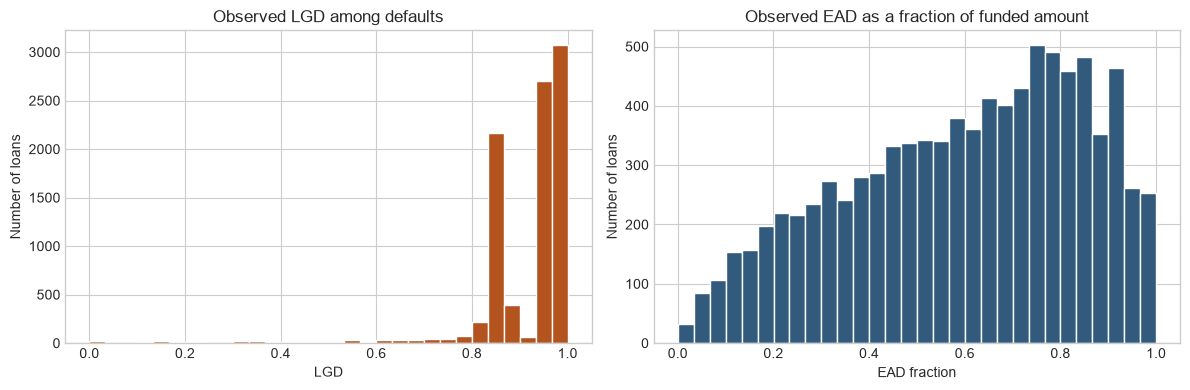

In [4]:
# Create a figure containing one row and two columns of charts.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

## FIRST COLUMN: distribution of observed LGD among defaulted loans.
# A histogram divides the LGD values into 30 intervals, called bins.
# The height of each bar shows the number of defaulted loans
# whose LGD falls within that interval.
axes[0].hist(defaults["lgd_observed"], bins=30, color="#b3541e", edgecolor="white")
axes[0].set(title="Observed LGD among defaults", xlabel="LGD", ylabel="Number of loans")

## SECOND COLUMN: distribution of the EAD fraction among defaulted loans.
# A histogram divides the EAD values into 30 intervals, called bins.
# The height of each bar shows the number of defaulted loans
# whose EAD falls within that interval.
axes[1].hist(defaults["ead_fraction"], bins=30, color="#315a7d", edgecolor="white")
axes[1].set(
    title="Observed EAD as a fraction of funded amount",
    xlabel="EAD fraction",
    ylabel="Number of loans",
)

plt.tight_layout()
plt.show()

## 2. Use only information known at origination

The LGD and EAD models must use predictors that were available when the loan was originated. Variables recorded after origination—such as final loan status, principal repaid, recoveries, collection fees and the constructed LGD and EAD outcomes—must not be used as predictors. Including them would create **outcome leakage** by giving the model information about the result it is supposed to forecast.

Because LGD and EAD describe the severity of loss **conditional on default**, these models are estimated using defaulted loans:

- **Development sample:** defaults from 2007–2011, used to prepare the data and estimate the models.
- **Test sample:** defaults from 2012, reserved for final out-of-vintage evaluation.

We use a small set of numerical predictors to keep the models transparent. Requested loan amount and monthly instalment are omitted because they overlap substantially with funded amount. Interest rate is known at origination and may contain useful information from the lender's earlier underwriting assessment, but its estimated relationship should be interpreted as predictive rather than causal.

Missing values are replaced using medians calculated from the development sample. Each predictor is then standardised using the development-sample mean and standard deviation:

$$z_{ij}=\frac{x_{ij}-\bar{x}_{j,\mathrm{development}}}
{s_{j,\mathrm{development}}}.$$

The fitted medians, means and standard deviations will later be applied unchanged to the 2012 data. This prevents information from the test period from entering model estimation.

**Predictor limitation:** These seven variables mostly describe borrower creditworthiness. The file also contains origination variables such as `grade`, `purpose` and `installment`, but adding them would require further model comparison using development/validation data. It does not contain collateral valuations, lien seniority, exact balance or date at default, or recovery timing. Thus our conditional LGD and EAD models may have limited predictive information. Do not use realised principal receipts or recoveries as origination predictors.

In [5]:
# List the predictor variables that were known when each loan was originated.
# These variables do not use repayment, recovery or final-status information.
severity_features = [
    "funded_amnt",
    "int_rate",
    "annual_inc",
    "dti",
    "delinq_2yrs",
    "inq_last_6mths",
    "revol_util",
]

# Select defaulted loans from 2007–2011 for model development.
# Each row is one defaulted loan.
development_defaults = defaults.loc[defaults["issue_year"] <= 2011].copy()

# Select defaulted loans from 2012 for final out-of-vintage evaluation.
# These rows are not used to fit the imputer, scaler or models.
test_defaults = defaults.loc[defaults["issue_year"] == 2012].copy()

# Select the predictor table for the development sample.
# Rows are defaulted loans and columns are the seven predictors listed above.
X_development = development_defaults[severity_features]

# Create the two preprocessing tools.
# The imputer will replace missing values with the development-sample median.
# The scaler will give each predictor a mean of approximately 0
# and a standard deviation of approximately 1 in the development sample.
imputer = SimpleImputer(strategy="median")
scaler = StandardScaler()

# Learn each column's median from the development data
# and replace any missing development values.
X_development = imputer.fit_transform(X_development)

# Learn each column's mean and standard deviation from the imputed
# development data and use them to standardise its values.
X_development = scaler.fit_transform(X_development)

# Add a column of ones for the GLM intercept.
# This allows the model to estimate a constant term.
X_development_glm = sm.add_constant(
    X_development,
    has_constant="add",
)

# Report the number of defaulted loans in each period.
print(f"Development defaults (2007–2011): {len(development_defaults):,}")
print(f"Test defaults (2012): {len(test_defaults):,}")
print("Preprocessing fitted using development data only.")

Development defaults (2007–2011): 3,227
Test defaults (2012): 5,856
Preprocessing fitted using development data only.


**Important distinction**

- `fit_transform()` learns the required values from the development data and immediately applies the transformation to those data. Here, the imputer learns the medians, while the scaler learns the means and standard deviations.
 - Later, `transform()` applies those already learned values to the 2012 test data without recalculating them.

This is the central **no-leakage rule** in this section: the 2012 test data must not influence how missing values are replaced or how predictors are standardised.

## 3. Predict conditional LGD and EAD with fractional logit

Notebook A predicted whether a loan would default. Its target was binary:
$$D_i =
\begin{cases}
1, & \text{if loan } i \text{ defaulted},\\
0, & \text{if loan } i \text{ was fully paid}.
\end{cases}$$

Notebook B asks a different question: **if default occurs, how severe is the loss?**

Observed LGD and the EAD fraction are not binary outcomes. They can take any value between zero and one. For example, a defaulted loan could have an LGD of 0.60, meaning that 60% of its exposure was not recovered.

### The fractional-logit mean

For either severity target $y_i$, fractional logit models its conditional mean as:
$$\mu_i
=
E(y_i\mid X_i,D_i=1)
=
\frac{1}{1+\exp[-(\beta_0+X_i^\top\beta)]}.$$


Here:

- $y_i$ is the observed LGD or EAD fraction;
- $X_i$ contains the loan's origination characteristics;
- $D_i=1$ indicates that the model is estimated among defaulted loans;
- $\beta_0$ is the intercept; and
- $\beta$ contains the predictor coefficients.

The logistic function keeps every predicted mean between zero and one.

### Connection to Notebook A

Binary logit and fractional logit use the same logistic-shaped mean function, but their outcomes and interpretations differ.

| Model | Observed outcome | Interpretation of prediction |
|---|---|---|
| Binary logit in Notebook A | Default indicator: 0 or 1 | Probability that the loan defaults |
| Fractional logit for LGD | Loss fraction between 0 and 1 | Average LGD among comparable defaulted loans |
| Fractional logit for EAD | EAD fraction between 0 and 1 | Average EAD fraction among comparable defaulted loans |

For example, a predicted LGD of 0.80 means that comparable defaulted loans are expected to lose, on average, 80% of their exposure. It does **not** mean that the loan has an 80% probability of default. Probability of default comes from Notebook A.

Notebook A used scikit-learn's regularised `LogisticRegression` because its target was binary. That estimator does not accept fractional outcomes such as 0.35 or 0.80. Here we use a binomial generalised linear model from `statsmodels` to estimate a fractional-response model.

### How the fractional model is estimated

The model estimates the coefficients by maximising:
$$Q(\beta)
=
\sum_i
\left[
y_i\log(\mu_i)
+
(1-y_i)\log(1-\mu_i)
\right].$$

For a binary target, this is the usual Bernoulli log-likelihood. For a fractional target, it is used as a **quasi-likelihood criterion for estimating the conditional mean**. We do not assume that fractional LGD itself follows a Bernoulli distribution.

Observed values of exactly zero and one are allowed, which is useful because some defaulted loans have no recorded loss while others have an LGD of 100%.

Note that `cov_type="HC0"` calculates robust standard errors. Fractional outcomes may have more or less variation than a binary model assumes. Robust standard errors provide more reliable measures of coefficient uncertainty. They do not change the fitted coefficients or predictions.

### The two severity targets

For LGD, the model estimates:
$$E(LGD_i\mid X_i,D_i=1).$$

For EAD, we first model the outstanding-balance fraction:
$$q_i
=
\frac{EAD_i^{proxy}}
{\text{funded amount}_i},
\qquad 0\le q_i\le 1.$$

We then convert the predicted fraction back into dollars:
$$\widehat{EAD}_i
=
\widehat q_i
\times
\text{funded amount}_i.$$

These are fully drawn instalment loans rather than undrawn revolving credit facilities. Therefore, we describe \(q_i\) as an **EAD fraction**, not a credit conversion factor.

### Model-design rule

Both models are pre-specified and estimated using only the 2007–2011 development defaults. The imputer and scaler fitted in the previous section are then applied unchanged to the 2012 predictors.

The 2012 LGD and EAD outcomes are not used to select predictors, fit preprocessing, estimate coefficients or choose between alternative models. They are used only in the later out-of-vintage evaluation.

A constant development-sample mean will later provide a transparent benchmark. If fractional logit does not improve on that benchmark, this is an empirical finding rather than a reason to change the model after viewing the test results.

### What does `sm.GLM()` receive?

`sm.GLM()` creates a generalised linear model. In this notebook it receives three main inputs:

1. **The outcome, $y$**  
   For the LGD model, this is `development_defaults["lgd_observed"]`.  
   For the EAD model, it is `development_defaults["ead_fraction"]`.

2. **The predictor matrix, $X$**  
   `X_development_glm` contains the standardised origination predictors. Each row represents one defaulted loan and each column represents one predictor. It also includes a column of ones for the intercept.

3. **The model family**  
   `family=sm.families.Binomial()` tells `statsmodels` to use the binomial GLM with its default logit link:

$$\mu_i
=
\frac{1}{1+\exp(-X_i^\top\beta)}.$$

For fractional outcomes, we use this logistic function to model the conditional mean. We are not claiming that LGD or the EAD fraction is a binary variable.

After defining the model, `.fit()` estimates the coefficients. The fitted model's `.predict()` method then calculates forecasts for new predictor rows.

### Why do we train LGD and EAD models using only defaulted loans?

LGD and EAD are defined **conditional on default**. Therefore, we train these models using loans that defaulted in the development sample (2007–2011).

For loans that never defaulted, LGD and exposure at default are not observed because no default occurred.

Once trained, the models can be applied to any loan using its origination characteristics. Their predictions answer: *If this borrower were to default, what loss fraction and outstanding exposure would we expect?*

We then combine these conditional predictions with PD to calculate expected loss for every loan in the portfolio.

**Key distinction:** We train LGD and EAD models using defaulted loans, but apply them to all loans when calculating expected loss.

In [6]:
# ------------------------------------------------------------
# Fit the conditional LGD model using 2007–2011 defaults
# ------------------------------------------------------------

# Step 1: Define the fractional-logit GLM.
# The outcome is the fraction of EAD that was not recovered.
lgd_glm = sm.GLM(
    development_defaults["lgd_observed"],  # Outcome y: observed LGD.
    X_development_glm,                     # Predictors X, including the intercept.
    family=sm.families.Binomial(),         # Use the logistic mean function.
)

# Step 2: Estimate the coefficients and save the fitted results.
lgd_model = lgd_glm.fit(
    cov_type="HC0"                         # Use robust coefficient standard errors.
)


# ------------------------------------------------------------
# Fit the conditional EAD-fraction model
# ------------------------------------------------------------

# Step 1: Define the fractional-logit GLM.
# The outcome is the EAD proxy divided by the original funded amount.
ead_fraction_glm = sm.GLM(
    development_defaults["ead_fraction"],  # Outcome y: observed EAD fraction.
    X_development_glm,                     # The same predictors and intercept.
    family=sm.families.Binomial(),         # Use the logistic mean function.
)

# Step 2: Estimate the coefficients and save the fitted results.
ead_fraction_model = ead_fraction_glm.fit(
    cov_type="HC0"                         # Use robust coefficient standard errors.
)

# Confirm that both estimation procedures successfully converged.
# A model that has not converged should not be used for prediction.
assert lgd_model.converged, "The LGD model did not converge."
assert ead_fraction_model.converged, "The EAD model did not converge."

print("LGD and EAD models fitted using the development data.")

LGD and EAD models fitted using the development data.


### From fitted models to 2012 forecasts

The two fitted model objects now contain the coefficients estimated from the 2007–2011 development defaults. We next use those fixed models to forecast conditional LGD and the EAD fraction for the 2012 defaults.

Before prediction, the 2012 predictor data must be prepared in exactly the same way as the development data:

1. select the same predictor columns in the same order;
2. replace missing values using the medians learned from 2007–2011;
3. standardise the predictors using the 2007–2011 means and standard deviations; and
4. add a column of ones for the intercept.

`statsmodels.GLM` does not automatically add an intercept. We therefore used `sm.add_constant()` for the development matrix and must add the same constant column to the 2012 matrix.

This differs from scikit-learn's `LogisticRegression` used in Notebook A, which includes an intercept automatically unless instructed otherwise.

For example, the test matrix before adding the constant might be:

$$X_{\text{test}}
=
\begin{bmatrix}
0.50 & -0.20\\
-1.00 & 0.80
\end{bmatrix}.$$

After adding the constant, it becomes:

$$X_{\text{test,GLM}}
=
\begin{bmatrix}
1 & 0.50 & -0.20\\
1 & -1.00 & 0.80
\end{bmatrix}.$$

The first column of ones allows the model to apply its estimated intercept $\beta_0$. The test matrix must have the same number and order of columns as the development matrix used to estimate the coefficients.

Only the 2012 origination predictors are passed to the fitted models. The observed 2012 LGD and EAD outcomes are not used to generate these forecasts.

In [7]:
# ------------------------------------------------------------
# Generate the 2012 forecasts
# ------------------------------------------------------------

# Select the same predictor columns for the 2012 defaulted loans.
# Each row is one 2012 defaulted loan.
# Each column is one origination predictor.
X_test_raw = test_defaults[severity_features]

# Fill missing values using the medians learned from 2007–2011.
# transform(), rather than fit_transform(), prevents 2012 from
# changing the preprocessing procedure.
X_test_imputed = imputer.transform(X_test_raw)

# Standardise the predictors using the means and standard deviations
# learned from the 2007–2011 development data.
X_test_scaled = scaler.transform(X_test_imputed)

# Add a column of ones so the test matrix includes the intercept.
# This gives the test matrix the same structure as X_development_glm.
X_test_glm = sm.add_constant(
    X_test_scaled,
    has_constant="add",
)

# Predict conditional LGD for each 2012 defaulted loan
# and save it beside the corresponding loan.
test_defaults["predicted_lgd"] = lgd_model.predict(X_test_glm)

# Predict the EAD fraction for each 2012 defaulted loan
# and save it beside the corresponding loan.
test_defaults["predicted_ead_fraction"] = (
    ead_fraction_model.predict(X_test_glm)
)

# Convert each loan's predicted EAD fraction into a dollar EAD.
# Pandas performs this multiplication row by row.
test_defaults["predicted_ead"] = (
    test_defaults["predicted_ead_fraction"]
    * test_defaults["funded_amnt"]
)

# Inspect the first five loan-level forecasts.
# Do not show the observed LGD or EAD yet because evaluation comes later.
display(
    test_defaults[
        [
            "funded_amnt",
            "predicted_lgd",
            "predicted_ead_fraction",
            "predicted_ead",
        ]
    ].head()
)

print("The 2012 LGD and EAD forecasts are now fixed.")

,funded_amnt,predicted_lgd,predicted_ead_fraction,predicted_ead
29103,15000,0.9529,0.6620,"9,929.5225"
29114,13100,0.9297,0.6640,"8,698.1481"
29124,10200,0.9367,0.6687,"6,820.7159"
29147,7500,0.9317,0.5296,"3,971.7850"
29158,5600,0.9003,0.6582,"3,685.7473"


The 2012 LGD and EAD forecasts are now fixed.


### Evaluate LGD on the held-out 2012 defaults

The fractional-logit model was estimated using defaults from 2007–2011, and its 2012 forecasts have already been fixed. We may now compare those forecasts with the observed LGDs of the 2012 defaulted loans.

We compare the model with a simple benchmark: the average LGD among the 2007–2011 development defaults. The benchmark gives every 2012 defaulted loan the same predicted LGD:

$$\widehat{LGD}^{\,benchmark}
=
\overline{LGD}_{development}.$$


A useful model should improve on this simple historical-average forecast when applied to the later cohort.

We evaluate the forecasts using two measures:
$$MAE
=
\frac{1}{n}
\sum_{i=1}^{n}
\left|
LGD_i-\widehat{LGD}_i
\right|,$$

and

$$RMSE
=
\sqrt{
\frac{1}{n}
\sum_{i=1}^{n}
\left(
LGD_i-\widehat{LGD}_i
\right)^2
}.$$

**MAE** is the average absolute distance between predicted and observed LGD. It is easy to interpret and gives each forecasting error proportional importance.

**RMSE** gives greater weight to large forecasting errors because the errors are squared before averaging. Minimising expected squared error targets the conditional mean, so RMSE is especially relevant for evaluating our fractional-logit mean forecast.

Both measures are reported in **LGD percentage points**. For example, an MAE of 7 percentage points means that predicted LGD differs from observed LGD by 0.07 on average. It does not mean that the model has a 7% relative error.

Lower MAE and RMSE values indicate more accurate forecasts. These measures give every defaulted loan equal weight, regardless of the loan's dollar exposure. Dollar-weighted loss evaluation is considered later when PD, LGD and EAD are combined.


In [8]:
# Store the observed LGDs for the held-out 2012 defaults.
# These outcomes are used only now, after the forecasts have been fixed.
actual_lgd = test_defaults["lgd_observed"]

# Calculate the average LGD among the 2007–2011 development defaults.
# This value is learned without using any 2012 outcomes.
mean_lgd_baseline = development_defaults["lgd_observed"].mean()

# Give every 2012 defaulted loan the same benchmark forecast.
# np.full() creates one value for each row in the 2012 test sample.
baseline_lgd = np.full(
    len(test_defaults),
    mean_lgd_baseline,
)

# Calculate MAE and RMSE for the benchmark and fractional-logit model.
# Multiplying by 100 converts decimal LGD errors into percentage points.
lgd_comparison = pd.DataFrame(
    {
        "MAE (percentage points)": [
            100 * mean_absolute_error(actual_lgd, baseline_lgd),
            100 * mean_absolute_error(actual_lgd, test_defaults["predicted_lgd"]),
        ],
        "RMSE (percentage points)": [
            100 * np.sqrt(
                mean_squared_error(actual_lgd, baseline_lgd)
            ),
            100 * np.sqrt(
                mean_squared_error(actual_lgd, test_defaults["predicted_lgd"])
            ),
        ],
    },
    index=[
        "Constant development mean",
        "Fractional-logit LGD",
    ],
)

# Display the comparison rounded to two decimal places.
# Lower values indicate more accurate forecasts.
display(lgd_comparison.round(2))

,MAE (percentage points),RMSE (percentage points)
Constant development mean,6.9600,10.0700
Fractional-logit LGD,6.9200,10.0600


### Interpretation

The fractional-logit model has a slightly lower MAE and RMSE than the constant development-mean benchmark:

- MAE decreases from 6.96 to 6.92 LGD percentage points.
- RMSE decreases from 10.07 to 10.06 LGD percentage points.

Both measures therefore favour the fractional-logit model, but the improvement is extremely small. For the 2012 cohort, the selected borrower and loan characteristics add little out-of-vintage forecasting accuracy beyond simply assigning every defaulted loan the historical development-sample mean LGD.

This does not mean that fractional logit is mathematically inappropriate. The weak improvement may reflect:

- the strong concentration of observed LGD near high values;
- **limited predictors of loss severity:** our models mainly use borrower credit characteristics, which may be more useful for predicting default than the amount lost after default;
- **missing important LGD information:** the dataset does not contain collateral values, loan seniority, recovery timing or detailed collection information;
- measurement error in the constructed LGD proxy;
- post-default collection decisions that are not known at origination; and
- differences between the development and 2012 vintages.

The result comes from one held-out origination cohort. It does not establish that the model will always outperform—or fail to outperform—the benchmark in future periods. Alternative models should not be selected by repeatedly examining the 2012 test results. Model selection would require a separate validation period within the development sample.

Finally, MAE and RMSE here evaluate errors in the **LGD fraction**, with every defaulted loan receiving equal weight. They do not yet evaluate errors in dollar credit losses. Dollar-loss performance is considered after PD, LGD and EAD are combined.

**Learning check:** If fractional logit improves only marginally on the historical average, why is the modelling exercise still useful? Consider the concentration of LGD outcomes, limitations of the available predictors and recovery data, and collection decisions made after default.

**Course-file results:** LGD RMSE is approximately 0.1006 for the model versus 0.1007 for the mean benchmark. MAE is about 0.0692 versus 0.0696. The improvement is very small; it does not justify a claim of strong borrower-level LGD forecasting.

### Evaluate EAD on the held-out 2012 defaults

We now evaluate how accurately our fractional-logit model predicts **Exposure at Default (EAD) in dollars** for loans that defaulted in 2012.

Although the model predicts EAD as a fraction of the original funded amount, we convert these predictions into dollars:

$$\widehat{EAD}_i=\widehat{EAD\ fraction}_i\times FundedAmount_i$$

We compare the model against a simple benchmark that uses the average EAD fraction from the development-period defaults. This benchmark applies the same fraction to every test loan but adjusts the dollar prediction according to its original funded amount.

We evaluate the forecasts using three measures:

- **MAE (USD):** Average absolute dollar prediction error.
- **RMSE (USD):** Similar to MAE, but penalises large dollar errors more heavily.
- **Mean prediction error (USD):** Indicates whether EAD is systematically overestimated (positive) or underestimated (negative).

Lower MAE and RMSE indicate better predictive accuracy. A mean prediction error close to zero indicates little overall bias, although individual errors may still be large.

**Why evaluate in dollars?** Dollar errors reflect the financial importance of prediction mistakes. A 10-percentage-point error produces a much larger monetary error for a $30,000 loan than for a $5,000 loan.

In [9]:
# ------------------------------------------------------------
# Evaluate EAD forecasts against a historical benchmark
# ------------------------------------------------------------

# STEP 1: Store the observed EAD for the held-out 2012 defaults.
# These outcomes are used only for evaluation, after forecasts are fixed.
actual_ead = test_defaults["ead_proxy"]

# STEP 2: Construct the historical benchmark.
# Calculate the mean EAD fraction from 2007–2011 development defaults.
# No 2012 outcomes are used to construct this benchmark.
mean_ead_fraction = development_defaults["ead_fraction"].mean()

# Give every 2012 defaulted loan the same benchmark EAD fraction.
# np.full() creates one value for each loan in the test sample.
baseline_ead_fraction = np.full(
    len(test_defaults),
    mean_ead_fraction,
)

# Convert the benchmark fractions into dollars.
# EAD in dollars = EAD fraction × original funded amount.
# Unlike LGD, we evaluate EAD in dollars rather than percentage points.
baseline_ead = (
    baseline_ead_fraction * test_defaults["funded_amnt"].to_numpy()
)

# STEP 3: Compare the benchmark and fractional-logit forecasts.
# MAE: average absolute dollar prediction error (lower is better).
# RMSE: gives greater weight to large dollar errors (lower is better).
# Mean prediction error:
#   Positive = overprediction on average.
#   Negative = underprediction on average.
ead_dollar_comparison = pd.DataFrame(
    {
        "MAE (USD)": [
            mean_absolute_error(actual_ead, baseline_ead),
            mean_absolute_error(
                actual_ead, test_defaults["predicted_ead"]
            ),
        ],
        "RMSE (USD)": [
            np.sqrt(mean_squared_error(actual_ead, baseline_ead)),
            np.sqrt(
                mean_squared_error(
                    actual_ead, test_defaults["predicted_ead"]
                )
            ),
        ],
        "Mean prediction error (USD)": [
            (baseline_ead - actual_ead.to_numpy()).mean(),
            (
                test_defaults["predicted_ead"] - actual_ead
            ).mean(),
        ],
    },
    index=[
        "Constant development mean",
        "Fractional-logit EAD",
    ],
)

# STEP 4: Display the comparison rounded to two decimal places.
display(ead_dollar_comparison.round(2))


,MAE (USD),RMSE (USD),Mean prediction error (USD)
Constant development mean,"2,368.8300","3,265.4900",131.1400
Fractional-logit EAD,"2,340.5400","3,271.8600",334.4700


### Interpretation

The fractional-logit model and the constant development-mean benchmark produce very similar EAD forecasting accuracy for the 2012 defaults:

- **MAE:** Fractional logit performs slightly better, reducing the average absolute dollar error from $2,368.83 to $2,340.54 (approximately 1.2%).
- **RMSE:** The historical benchmark performs slightly better, with an RMSE of $3,265.49 compared with $3,271.86 for fractional logit.
- **Mean prediction error:** Both methods overpredict EAD on average, but fractional logit has a larger positive bias ($334.47 versus $131.14 per loan).

Overall, neither method consistently outperforms the other. The fractional-logit model provides only a small improvement in MAE, while the historical benchmark performs slightly better on RMSE and average prediction bias.

The weak improvement may reflect:

- **Limited predictors of EAD:** Our models mainly use borrower credit characteristics, which may be more useful for predicting default than the outstanding exposure when default occurs.
- **Missing important information:** The dataset does not contain the exact balance at default, timing of default or detailed repayment history.
- **Measurement limitations:** We use a constructed EAD proxy rather than the directly observed outstanding balance at default.
- **Differences between loan vintages:** Relationships estimated using development-period defaults may not generalise perfectly to the 2012 defaults.

These results come from one held-out cohort and do not establish how the models would perform in other periods.

**Key takeaway:** A more sophisticated model does not necessarily produce more accurate forecasts. In this dataset, the additional borrower and loan characteristics provide little improvement over a simple historical-average approach.

**Learning check:** Why might borrower characteristics help predict whether a loan defaults (PD), but provide limited information about how much principal remains outstanding when default occurs (EAD)?

## 4. Check LGD and EAD calibration

MAE and RMSE measure average prediction errors, but they do not tell us whether the model systematically overpredicts or underpredicts losses for different groups of loans.

**Calibration** compares average predicted values with average observed values.

We examine LGD and EAD separately:

1. **LGD calibration:** Divide the 2012 defaulted loans into five groups based on predicted LGD, from lowest to highest.
2. **EAD calibration:** Divide the same loans into five groups based on predicted EAD fraction.

For each group, we calculate:

- The average predicted value.
- The average observed value.
- The number of defaulted loans.

If predicted and observed averages are close, the model is reasonably calibrated for that group. Large differences indicate overprediction or underprediction.

**Important:** We use only defaulted loans because LGD and EAD are conditional on default. The five groups are formed using predictions, not observed outcomes, so the grouping does not use realised severity to determine group membership.

This analysis evaluates LGD and EAD separately. Later, we combine them with PD to evaluate expected credit loss (EL) for the entire loan portfolio.

In [10]:
# ------------------------------------------------------------
# Check LGD and EAD calibration for the 2012 defaults
# ------------------------------------------------------------

# STEP 1: Divide loans into five groups based on predicted LGD.
# pd.qcut() creates groups with approximately equal numbers of loans.
# Group 1 contains the lowest predicted LGDs; Group 5 the highest.
# duplicates="drop" handles cases where identical predictions
# prevent five distinct groups from being formed.
test_defaults["LGD group"] = pd.qcut(
    test_defaults["predicted_lgd"],
    5,
    duplicates="drop",
)

# STEP 2: Compare average predicted and observed LGD in each group.
# "mean" calculates the group average.
# "size" counts the number of defaulted loans in each group.
lgd_calibration = test_defaults.groupby(
    "LGD group", observed=True
).agg(
    predicted=("predicted_lgd", "mean"),
    observed=("lgd_observed", "mean"),
    defaults=("lgd_observed", "size"),
)

display(lgd_calibration.round(3))


# STEP 3: Repeat the same analysis for EAD fractions.
# We use EAD fractions because the fractional-logit model
# directly predicts the proportion of the original funded amount.
test_defaults["EAD group"] = pd.qcut(
    test_defaults["predicted_ead_fraction"],
    5,
    duplicates="drop",
)

# STEP 4: Compare average predicted and observed EAD fractions.
ead_calibration = test_defaults.groupby(
    "EAD group", observed=True
).agg(
    predicted=("predicted_ead_fraction", "mean"),
    observed=("ead_fraction", "mean"),
    defaults=("ead_fraction", "size"),
)

display(ead_calibration.round(3))


,predicted,observed,defaults
LGD group,,,
"(0.832, 0.916]",0.9080,0.9040,1172
"(0.916, 0.921]",0.9190,0.9110,1171
"(0.921, 0.925]",0.9230,0.9130,1171
"(0.925, 0.93]",0.9270,0.9120,1171
"(0.93, 0.955]",0.9350,0.9190,1171


,predicted,observed,defaults
EAD group,,,
"(0.51, 0.583]",0.5590,0.5580,1172
"(0.583, 0.606]",0.5950,0.5820,1171
"(0.606, 0.63]",0.6170,0.5770,1171
"(0.63, 0.651]",0.6410,0.6110,1171
"(0.651, 0.726]",0.6670,0.6320,1171


### Plot predicted against observed severity

We now visualise the LGD and EAD calibration results from the previous section.

Each point represents one of the five groups of defaulted loans, ordered from lowest to highest predicted severity.

- **Horizontal axis:** Average predicted LGD or EAD fraction.
- **Vertical axis:** Average observed LGD or EAD fraction.
- **Dotted diagonal:** Perfect calibration, where predicted and observed averages are equal.

**How to interpret the graphs:**

- Points **on the diagonal** indicate accurate average predictions for that group.
- Points **above the diagonal** indicate underprediction (actual severity is higher than predicted).
- Points **below the diagonal** indicate overprediction (actual severity is lower than predicted).

We also examine whether observed severity generally increases as predicted severity increases. This indicates whether the model can distinguish between loans with relatively higher and lower severity.

**Important:** Each point represents a group average, not an individual loan. The graphs evaluate LGD and EAD separately for the 2012 defaults, not the complete expected loss of the portfolio.

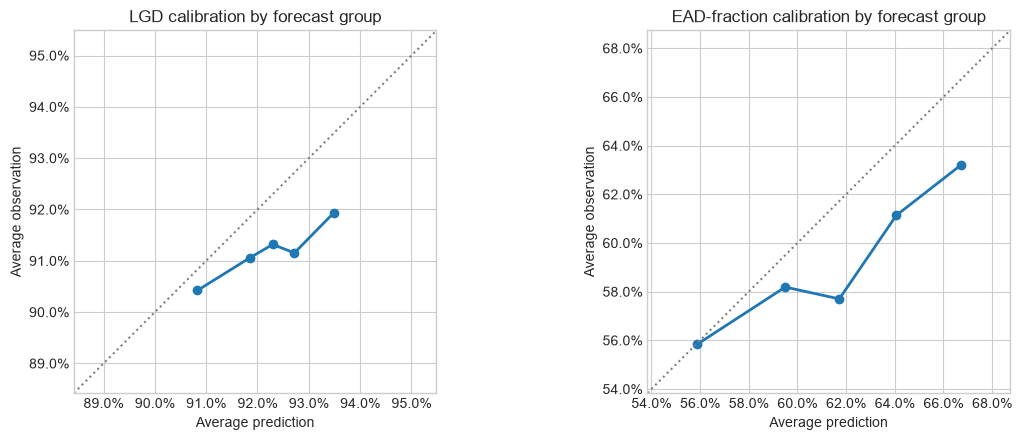

In [11]:
# ------------------------------------------------------------
# Plot LGD and EAD calibration for the 2012 defaults
# ------------------------------------------------------------

# STEP 1: Create two graphs side by side.
# The first shows LGD calibration; the second shows EAD calibration.
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# STEP 2: Plot the average predicted and observed values for each group.
# Each point represents approximately one-fifth of the 2012 defaults.
for table, title, ax in [
    (lgd_calibration, "LGD calibration by forecast group", axes[0]),
    (ead_calibration, "EAD-fraction calibration by forecast group", axes[1]),
]:

    # Plot average observed severity against average predicted severity.
    ax.plot(
        table["predicted"],
        table["observed"],
        marker="o",
        linewidth=2,
    )

    # Use the same scale on both axes for a fair comparison.
    # Add a small margin so the points are not at the graph edges.
    lower = min(table["predicted"].min(), table["observed"].min()) - 0.02
    upper = max(table["predicted"].max(), table["observed"].max()) + 0.02

    # Draw the 45-degree diagonal representing perfect calibration.
    # Above the line = underprediction; below = overprediction.
    ax.plot(
        [lower, upper],
        [lower, upper],
        color="grey",
        linestyle=":",
    )

    # Add titles, labels and matching axis limits.
    ax.set(
        title=title,
        xlabel="Average prediction",
        ylabel="Average observation",
        xlim=(lower, upper),
        ylim=(lower, upper),
        aspect="equal",
    )

    # Display decimal fractions as percentages (e.g., 0.90 = 90%).
    ax.xaxis.set_major_formatter(PercentFormatter(1))
    ax.yaxis.set_major_formatter(PercentFormatter(1))

# STEP 3: Adjust spacing and display the graphs.
plt.tight_layout()
plt.show()


### Interpretation

**LGD calibration (left graph)**

- Predicted LGD increases from approximately 90.8% to 93.5%, but observed LGD increases only from approximately 90.4% to 91.9%.
- Most points lie below the diagonal, indicating that the model generally overpredicts LGD, particularly for groups with higher predicted severity.
- The narrow range of predictions and observed outcomes suggests limited ability to distinguish between loans with different loss severities.

**EAD calibration (right graph)**

- Predicted EAD fractions increase from approximately 55.9% to 66.7%.
- Observed EAD fractions generally increase from approximately 55.8% to 63.2%, suggesting some ability to distinguish loans with different exposures.
- Most points lie below the diagonal, indicating that the model tends to overpredict EAD, especially in the higher forecast groups.

**Overall:** The EAD model shows more useful differentiation across forecast groups than the LGD model, although neither is perfectly calibrated. These results are consistent with the limited forecasting improvements observed earlier.

**Learning check:** Why might a model produce predictions that increase across risk groups but still systematically overestimate the observed outcomes?

## 5. Predict LGD and EAD for every 2012 loan

So far, we have trained LGD and EAD models using historical defaults and evaluated them using the 2012 defaults.

However, to calculate **Expected Loss (EL)**, we need predictions for **every loan in the 2012 portfolio**, including loans that did not default.

Although LGD and EAD models are trained only on defaulted loans, they can be applied to any loan using its origination characteristics.

Their predictions answer two hypothetical questions:

- **Predicted LGD:** If this borrower defaults, what proportion of the exposure would we expect to lose?
- **Predicted EAD:** If this borrower defaults, how much would we expect to be outstanding?

We use the previously fitted models to predict LGD and EAD for all 2012 loans. We do not retrain the models or use the actual 2012 default outcomes.

In the next section, we combine these predictions with PD from Lecture 9 to calculate expected loss for every loan.

**Key distinction:** LGD and EAD models are trained using defaulted loans, but expected loss must be calculated for the entire loan portfolio.

In [12]:
# ------------------------------------------------------------
# Predict LGD and EAD for every loan in the 2012 test cohort
# ------------------------------------------------------------

# 1: Select all loans originated in 2012.
# Unlike the earlier evaluation, we now include both defaulted
# and non-defaulted loans because EL applies to the entire portfolio.
test_loans = loans.loc[loans["issue_year"] == 2012].copy()

# 2: Prepare the predictors using the fitted preprocessing.
# The imputer fills missing values using development-period information.
# The scaler standardises the predictors using development-period values.
# We use transform(), NOT fit_transform(), to avoid learning from test data.
X_all_test = imputer.transform(test_loans[severity_features])
X_all_test = scaler.transform(X_all_test)

# Add the constant (intercept) required by the fractional-logit models.
X_all_test_glm = sm.add_constant(X_all_test, has_constant="add")

# 3: Predict conditional LGD and EAD fractions for every loan.
# These predictions describe what we expect IF the borrower defaults.
# The actual default outcome is not used to generate these forecasts.
test_loans["predicted_lgd"] = lgd_model.predict(X_all_test_glm)
test_loans["predicted_ead_fraction"] = (
    ead_fraction_model.predict(X_all_test_glm)
)

# 4: Convert the predicted EAD fraction into dollars.
# Predicted EAD = predicted fraction × original funded amount.
test_loans["predicted_ead"] = (
    test_loans["predicted_ead_fraction"] * test_loans["funded_amnt"]
)

# 5: Check that every test loan has a predicted PD.
# PD predictions were imported from Lecture 9 earlier in the notebook.
# The assertion stops execution if any PD prediction is missing.
assert test_loans["predicted_pd"].notna().all()

# Display the first five loans and their predictions.
display(
    test_loans[
        ["funded_amnt", "predicted_pd", "predicted_lgd", "predicted_ead"]
    ].head()
)

,funded_amnt,predicted_pd,predicted_lgd,predicted_ead
29096,32875,0.0609,0.9345,"18,386.4108"
29097,21000,0.0824,0.9407,"12,269.3101"
29098,5000,0.0561,0.9189,"2,633.2842"
29099,24000,0.0410,0.9311,"13,256.9615"
29100,7600,0.0317,0.9260,"3,978.9842"


## 6. Combine PD, LGD and EAD to calculate Expected Loss

We now combine the predictions from Lectures 9 and 10 to estimate **Expected Loss (EL)** for every loan in the 2012 test portfolio.

For each loan:

$$\widehat{EL}_i=\widehat{PD}_i\times\widehat{LGD}_i\times\widehat{EAD}_i$$

Where:

- **PD:** Predicted probability that the borrower defaults.
- **LGD:** Predicted proportion of exposure lost if default occurs.
- **EAD:** Predicted dollar exposure if default occurs.

We calculate EL for **all loans**, including those that did not default, because their future default outcomes were unknown when the predictions were made.

### Predicted EL versus realised loss

We distinguish between two quantities:

**1. Predicted Expected Loss**

Calculated using the PD, LGD and EAD forecasts. It represents the expected monetary loss before observing the loan outcome.

**2. Realised Loss**

Calculated after observing the loan outcome:

- If the loan did not default, its realised default loss is zero.
- If the loan defaulted, we estimate its realised loss using the outstanding-principal and net-recovery proxies constructed from the dataset.

For defaulted loans:
$$\text{Realised loss proxy}
=\max(0,\text{EAD proxy}-\text{Net recovery})$$

We then calculate total portfolio expected loss by adding the individual loan forecasts:

$$\widehat{EL}_{portfolio}=\sum_{i=1}^{N}\widehat{EL}_i$$

Finally, we compare the total predicted EL with the total realised loss proxy for the 2012 portfolio.

**Important modelling assumption:** Multiplying separately predicted LGD and EAD assumes that their conditional dependence does not materially affect expected loss. The product is therefore an approximation to the exact conditional expected loss.

**Learning check:** Why can a loan have a positive predicted expected loss but zero realised loss?

In [13]:
# ------------------------------------------------------------
# 1: Calculate predicted Expected Loss for every 2012 loan
# ------------------------------------------------------------

# Combine the three forecasts:
# Expected Loss = Probability of Default × LGD × EAD.
# These forecasts were produced without using actual 2012 outcomes.
test_loans["predicted_el"] = (
    test_loans["predicted_pd"]
    * test_loans["predicted_lgd"]
    * test_loans["predicted_ead"]
)

# ------------------------------------------------------------
# 2: Calculate realised loss using actual loan outcomes
# ------------------------------------------------------------
# We need the original loan amount, principal repayments,
# recoveries and collection costs to construct realised losses.
measurement_columns = [
    "funded_amnt",
    "total_rec_prncp",
    "recoveries",
    "collection_recovery_fee",
]

# Check that defaulted loans have valid loss measurements.
# Missing or negative values could make portfolio losses incorrect.
measurement_ok = (
    test_loans[measurement_columns].notna().all(axis=1)
    & test_loans[measurement_columns].ge(0).all(axis=1)
    & test_loans["funded_amnt"].gt(0)
)

assert (measurement_ok | test_loans["default"].eq(0)).all(), (
    "Some defaulted loans have missing or invalid loss measurements."
)

# Estimate the outstanding principal not recovered through repayments.
# This is an EAD proxy, not the exact balance at the default date.
test_loans["ead_proxy"] = (
    test_loans["funded_amnt"] - test_loans["total_rec_prncp"]
).clip(lower=0)

# Calculate net recoveries after collection costs.
# Negative net recoveries are set to zero in this teaching proxy.
test_loans["net_recovery"] = (
    test_loans["recoveries"] - test_loans["collection_recovery_fee"]
).clip(lower=0)

# For defaulted loans, realised loss is the remaining exposure
# minus net recoveries, with a minimum loss of zero.
# Non-defaulted loans have zero realised default loss.
test_loans["realised_loss"] = np.where(
    test_loans["default"] == 1,
    (test_loans["ead_proxy"] - test_loans["net_recovery"]).clip(lower=0),
    0.0,
)

# Check that all predicted and realised losses are valid numbers.
# This prevents missing values from silently affecting portfolio totals.
assert np.isfinite(test_loans["predicted_el"]).all()
assert np.isfinite(test_loans["realised_loss"]).all()

# ------------------------------------------------------------
# 3: Calculate total predicted and realised portfolio loss
# ------------------------------------------------------------

total_funded = test_loans["funded_amnt"].sum()
total_predicted_el = test_loans["predicted_el"].sum()
total_realised_loss = test_loans["realised_loss"].sum()

# ------------------------------------------------------------
# 4: Summarise the 2012 portfolio results
# ------------------------------------------------------------

# Loss / funded amount expresses the portfolio loss as a
# proportion of the original amount lent.
portfolio_summary = pd.Series(
    {
        "Loans": len(test_loans),
        "Total funded amount": total_funded,
        "Predicted expected loss": total_predicted_el,
        "Realised loss proxy": total_realised_loss,
        "Predicted EL / funded amount": total_predicted_el / total_funded,
        "Realised loss / funded amount": total_realised_loss / total_funded,
    },
    name="2012 portfolio",
)

display(portfolio_summary.to_frame())

,2012 portfolio
Loans,"43,344.0000"
Total funded amount,"505,924,250.0000"
Predicted expected loss,"37,589,946.0417"
Realised loss proxy,"36,557,622.8579"
Predicted EL / funded amount,0.0743
Realised loss / funded amount,0.0723


### Interpretation

The 2012 test portfolio contains **43,344 loans**, with a total original funded amount of approximately **$505.92 million**.

Our models predict total expected credit losses of **$37.59 million**, compared with a realised loss proxy of **$36.56 million**.

- **Predicted loss rate:** 7.43% of the original funded amount.
- **Realised loss rate:** 7.23% of the original funded amount.
- **Difference:** The model overpredicts portfolio losses by approximately $1.03 million, or 0.20 percentage points of the funded amount.

The predicted and realised portfolio losses are relatively close, suggesting reasonable aggregate forecasting accuracy for this cohort.

However, this does not necessarily mean the model accurately predicts losses for individual loans or different borrower groups. Overprediction for some loans may offset underprediction for others.

Furthermore, realised losses are based on constructed LGD and EAD proxies rather than complete economic loss measurements.

**Key takeaway:** Combining PD, LGD and EAD allows us to estimate monetary credit losses for an entire portfolio. However, accurate total expected loss does not guarantee accurate predictions for individual borrowers.

**Learning check:** How could a model predict total portfolio losses reasonably well while making substantial errors for individual loans?

## 7. Check expected-loss calibration across forecast groups

We now evaluate whether our combined **PD × LGD × EAD** forecasts accurately predict credit losses across different groups of loans.

Unlike the earlier LGD and EAD evaluations, this analysis includes **all 2012 loans**, including those that never defaulted.

Every loan receives a predicted expected loss. However, loans that did not default have zero realised default loss.

To compare loans of different sizes, we express each loan's predicted EL as a fraction of its original funded amount:
$$\text{Predicted loss fraction}_i
=\frac{\widehat{EL}_i}{FundedAmount_i}$$

We then divide loans into five approximately equal-sized groups, from lowest to highest predicted loss fraction.

For each group, we calculate the total predicted EL and realised loss, expressing both as a percentage of the group's total funded amount.

**Interpreting the graph:**

- **On the diagonal:** Predicted and realised loss rates are equal.
- **Above the diagonal:** Realised losses exceed predictions (underprediction).
- **Below the diagonal:** Predicted losses exceed realised losses (overprediction).

**Key distinction:** These groups are based on predicted loss risk, not actual default outcomes. A group may contain many nondefaulted loans but still have positive expected losses.

,loans,defaults,funded,expected,realised,Expected / funded,Realised / funded
EL group,,,,,,,
"(-0.001, 0.0351]",8669,489,105187850,"2,570,475.0910","2,928,577.4690",0.0240,0.0280
"(0.0351, 0.0548]",8669,865,100088250,"4,496,589.5790","5,128,880.8730",0.0450,0.0510
"(0.0548, 0.0765]",8668,1116,98452250,"6,423,966.4140","6,557,332.4180",0.0650,0.0670
"(0.0765, 0.109]",8669,1428,99965650,"9,080,702.5840","8,571,060.3760",0.0910,0.0860
"(0.109, 0.436]",8669,1958,102230250,"15,018,212.3740","13,371,771.7230",0.1470,0.1310


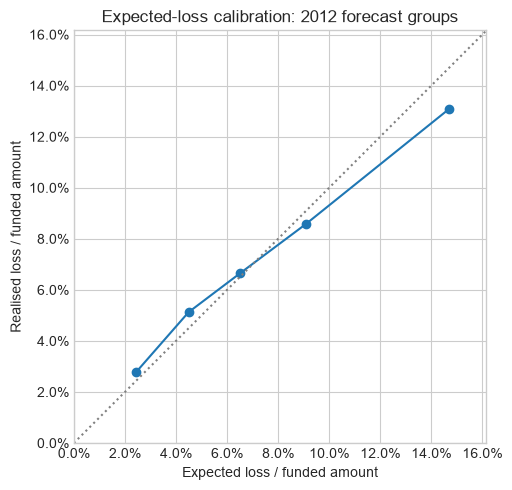

In [14]:
# ------------------------------------------------------------
# Evaluate expected-loss calibration across the 2012 portfolio
# ------------------------------------------------------------

# Express each loan's predicted EL as a fraction of its funded amount.
# This allows loans of different sizes to be compared.
test_loans["predicted_loss_fraction"] = (
    test_loans["predicted_el"] / test_loans["funded_amnt"]
)

# Divide all 2012 loans into five groups based on predicted loss fraction.
# pd.qcut() creates groups with approximately equal numbers of loans.
# The groups are formed using predictions, not realised outcomes.
test_loans["EL group"] = pd.qcut(
    test_loans["predicted_loss_fraction"],
    5,
    duplicates="drop",
)

# Summarise predicted and realised losses within each group.
# "size" counts loans; "sum" counts defaults or adds dollar amounts.
el_calibration = test_loans.groupby("EL group", observed=True).agg(
    loans=("default", "size"),
    defaults=("default", "sum"),
    funded=("funded_amnt", "sum"),
    expected=("predicted_el", "sum"),
    realised=("realised_loss", "sum"),
)

# Convert total expected and realised losses into portfolio loss rates.
# Each group's total funded amount is the denominator.
el_calibration["Expected / funded"] = (
    el_calibration["expected"] / el_calibration["funded"]
)
el_calibration["Realised / funded"] = (
    el_calibration["realised"] / el_calibration["funded"]
)

# Display the results for all five forecast groups.
display(el_calibration.round(3))

# ------------------------------------------------------------
# Plot expected versus realised loss rates
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(6, 5))

# Each point represents one group of approximately equal numbers of loans.
# The horizontal axis shows predicted loss rates; vertical shows realised.
ax.plot(
    el_calibration["Expected / funded"],
    el_calibration["Realised / funded"],
    marker="o",
)

# Add a 45-degree reference line for perfect calibration.
# Above the line = underprediction; below = overprediction.
upper = 1.1 * el_calibration[
    ["Expected / funded", "Realised / funded"]
].max().max()

ax.plot([0, upper], [0, upper], color="grey", linestyle=":")

# Use the same scale on both axes so the diagonal represents equality.
ax.set(
    xlim=(0, upper),
    ylim=(0, upper),
    aspect="equal",
    xlabel="Expected loss / funded amount",
    ylabel="Realised loss / funded amount",
    title="Expected-loss calibration: 2012 forecast groups",
)

# Display loss fractions as percentages.
ax.xaxis.set_major_formatter(PercentFormatter(1))
ax.yaxis.set_major_formatter(PercentFormatter(1))

plt.tight_layout()
plt.show()

### Interpretation

The combined expected-loss model shows reasonably good calibration across the five forecast groups, although some systematic differences remain.

- **Risk differentiation:** Realised loss rates increase from 2.8% in the lowest predicted-loss group to 13.1% in the highest group. This suggests that the model successfully distinguishes between groups with lower and higher credit losses.
- **Lower-risk groups:** The model slightly underpredicts losses. For example, the lowest group's predicted loss rate is 2.4%, compared with a realised rate of 2.8%.
- **Middle group:** Predicted and realised loss rates are very close (6.5% versus 6.7%).
- **Higher-risk groups:** The model overpredicts losses. In the highest group, the predicted loss rate is 14.7%, compared with a realised rate of 13.1%.

Overall, the model captures the increasing pattern of credit losses across forecast groups, but it tends to underestimate losses in lower-risk groups and overestimate them in higher-risk groups.

This demonstrates why evaluating only total portfolio expected loss is insufficient. Even when aggregate predictions are close to realised losses, the model may be less accurate for particular groups of borrowers.

**Key takeaway:** A useful credit-risk model should both distinguish between borrowers with different levels of risk and produce reasonably accurate expected-loss estimates for those groups.

**Learning check:** If a bank systematically overpredicts expected losses for its highest-risk borrowers, how might this affect lending decisions, loan pricing or capital allocation?

## 8. Where does portfolio expected loss come from?

We have calculated the total expected loss for the 2012 portfolio. But which borrowers contribute most to these losses?

To investigate, we divide all 2012 loans into five approximately equal-sized groups based on their **predicted Probability of Default (PD)**, from lowest to highest.

For each group, we calculate the average predicted PD, LGD and EAD, together with the total predicted and realised dollar losses.

This helps us understand how default probability, loss severity and exposure jointly influence portfolio expected loss.

**Difference from Section 7:** Previously, we grouped loans by their predicted EL relative to funded amount to evaluate calibration. Here, we group loans by predicted PD to investigate where portfolio losses are concentrated.

Both analyses include defaulted and nondefaulted loans.

**Important:** A higher PD does not necessarily mean a higher dollar expected loss. Loan size and predicted LGD and EAD also matter.

,loans,average_pd,average_lgd,average_ead,predicted_el,realised_loss
PD band,,,,,,
"(-0.001, 0.0673]",8669,0.0500,0.9200,"6,760.9700","2,626,321.6900","2,966,971.4000"
"(0.0673, 0.101]",8669,0.0800,0.9200,"6,731.9400","4,538,727.2200","5,166,506.8500"
"(0.101, 0.136]",8668,0.1200,0.9200,"6,908.0100","6,514,760.8200","6,561,921.4400"
"(0.136, 0.186]",8669,0.1600,0.9200,"7,187.4900","9,102,187.4100","8,702,065.8800"
"(0.186, 0.666]",8669,0.2400,0.9200,"7,599.1000","14,807,948.9000","13,160,157.2800"


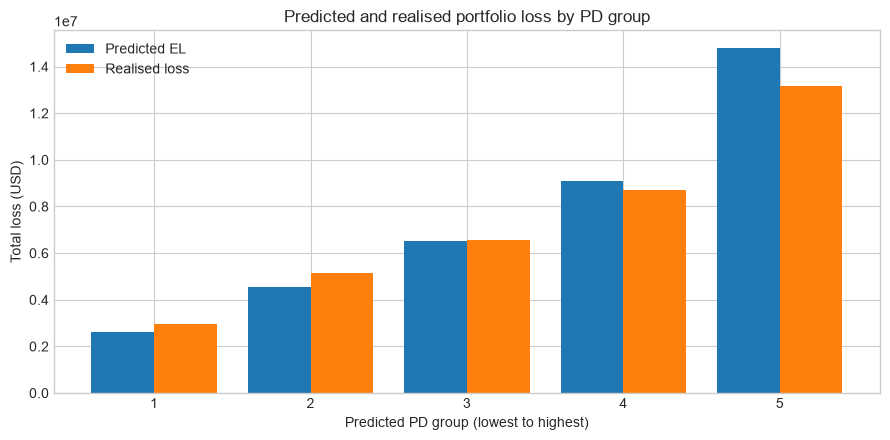

In [15]:
# ------------------------------------------------------------
# Examine portfolio expected loss across predicted PD groups
# ------------------------------------------------------------

# Divide all 2012 loans into five groups based on predicted PD.
# pd.qcut() creates approximately equal-sized groups.
# The first group has the lowest predicted PD; the fifth the highest.
test_loans["PD band"] = pd.qcut(
    test_loans["predicted_pd"], 5, duplicates="drop"
)

# Summarise the credit-risk components and total losses in each group.
# Mean PD, LGD and EAD describe the average predictions within a group.
# Total predicted EL and realised loss are measured in dollars.
el_by_pd_band = test_loans.groupby("PD band", observed=True).agg(
    loans=("predicted_pd", "size"),
    average_pd=("predicted_pd", "mean"),
    average_lgd=("predicted_lgd", "mean"),
    average_ead=("predicted_ead", "mean"),
    predicted_el=("predicted_el", "sum"),
    realised_loss=("realised_loss", "sum"),
)

display(el_by_pd_band.round(2))

# ------------------------------------------------------------
# Compare predicted and realised dollar losses across PD groups
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(9, 4.5))

# Create one position for each PD group.
x = np.arange(len(el_by_pd_band))

# Plot predicted and realised losses side by side for comparison.
ax.bar(
    x - 0.2,
    el_by_pd_band["predicted_el"],
    0.4,
    label="Predicted EL",
)
ax.bar(
    x + 0.2,
    el_by_pd_band["realised_loss"],
    0.4,
    label="Realised loss",
)

# Label groups from lowest (1) to highest (5) predicted PD.
ax.set(
    title="Predicted and realised portfolio loss by PD group",
    xlabel="Predicted PD group (lowest to highest)",
    ylabel="Total loss (USD)",
    xticks=x,
    xticklabels=range(1, len(x) + 1),
)

ax.legend()
plt.tight_layout()
plt.show()


### Interpretation

The results show that expected credit losses increase substantially across groups with higher predicted probabilities of default.

- **PD:** Average predicted PD increases from 5% in the lowest-risk group to 24% in the highest-risk group.
- **LGD:** Average predicted LGD remains close to 92% across all groups, suggesting that the LGD model provides limited differentiation between borrowers.
- **EAD:** Average predicted EAD increases moderately, from approximately $6,761 to $7,599.
- **Expected loss:** Total predicted EL increases from approximately $2.63 million in the lowest-PD group to $14.81 million in the highest-PD group.

The highest-PD group accounts for approximately **39% of total predicted portfolio expected loss**, despite containing only 20% of the loans.

Comparing predicted and realised losses also reveals a systematic pattern:

- The model underpredicts losses in the two lowest-PD groups.
- Predictions are close to realised losses in the middle group.
- The model overpredicts losses in the two highest-PD groups.

**Key takeaway:** In this portfolio, differences in predicted default probabilities explain much of the variation in expected losses across groups. LGD varies very little, while EAD contributes more moderately.

**Learning check:** Why does the highest-PD group account for such a large share of expected portfolio losses, even though it contains only one-fifth of the loans?

### Save the test-cohort results

This cell writes `outputs/expected_loss_test_results.csv`, with loan identifiers, forecasts and recorded outcomes. Running it again replaces that output file.

In [16]:
output_columns = [
    "id",
    "issue_date",
    "funded_amnt",
    "predicted_pd",
    "predicted_lgd",
    "predicted_ead",
    "predicted_el",
    "default",
    "realised_loss",
]
test_loans[output_columns].to_csv(
    OUTPUT_DIR / "expected_loss_test_results.csv", index=False
)
print("Saved outputs/expected_loss_test_results.csv")

Saved outputs/expected_loss_test_results.csv


## 9. Optional extension: Stress testing expected credit losses

Banks use stress testing to examine how credit losses might change under adverse economic conditions, such as a recession or rising unemployment.

Our models estimate expected loss under the conditions represented by the historical data. We can also explore hypothetical scenarios in which borrowers become more likely to default or lenders recover less following default.

Recall:

$$EL=PD\times LGD\times EAD$$

**Optional exercise**

Using the predicted PD, LGD and EAD for the 2012 portfolio, investigate the following hypothetical stress scenario:

- **PD increases by 30%** relative to its original predicted value.
- **LGD increases by 5 percentage points** (e.g., from 90% to 95%).
- **EAD remains unchanged.**

Recalculate expected loss for each loan under the stressed assumptions and compare total stressed portfolio EL with the original predicted portfolio EL.

When applying the stress, remember that PD and LGD cannot exceed 100%.

**Questions to consider**

1. How much does total portfolio expected loss increase in dollars and as a percentage?
2. Which change has the greater effect on expected loss: higher PD or higher LGD?
3. What additional information would a bank need to develop a more realistic recession stress scenario?

**Important:** This is a simplified sensitivity exercise, not a fully specified macroeconomic stress-testing model. In practice, PD, LGD and EAD may change together under adverse economic conditions.

## 10. Interpret the results and recognise the limitations

We have estimated LGD and EAD, combined them with PD, and evaluated expected credit losses for the 2012 loan portfolio.

Although the combined model predicts total portfolio losses reasonably closely, several limitations are important:

1. **LGD and EAD are based on proxies.** The dataset does not contain the exact outstanding balance at default or complete recovery timing information. Our calculations simplify actual credit losses and do not discount future recoveries.

2. **Important predictors are missing.** Our seven predictors mainly describe borrower creditworthiness and may be more suitable for predicting PD than LGD or EAD. The dataset lacks important information about collateral, loan seniority, repayment history, default timing and recovery processes. These limitations may help explain the relatively weak forecasting improvements observed in our LGD and EAD models.

3. **LGD and EAD are conditional models.** They are trained using historical defaults and applied to all loans. Combining their separate predictions assumes that conditional dependence between LGD and EAD does not materially affect expected loss.

4. **Evaluation is limited to one test cohort.** We evaluate loans originated in 2012. Reliable forecasting requires testing across additional periods and changing economic conditions.

5. **Expected loss is not unexpected loss.** EL estimates the average loss expected under the model. Unexpected loss concerns variation around that expectation and is important for bank capital management.

6. **This is a teaching model, not a regulatory model.** A production model would require more complete data, additional validation and governance. IFRS 9 also requires considerations such as staging, forward-looking scenarios and discounted cash shortfalls that are not implemented here.

### Final learning check

Before trusting an expected-loss forecast, consider:

- Are PD, LGD and EAD defined consistently?
- Were the models trained without using information from the test period?
- Did the LGD and EAD models improve on their historical benchmarks?
- Does the combined model predict portfolio losses accurately across different risk groups?
- What additional information would improve the reliability of the forecasts?

**Key takeaway:** Accurate credit-risk modelling depends on appropriate data, consistent definitions and reliable evaluation. More sophisticated models cannot compensate for missing information, data leakage or incorrectly measured exposures.

## Further reading and reproducibility

- Papke, L. E. and Wooldridge, J. M. (1996), “Econometric Methods for Fractional Response Variables with an Application to 401(k) Plan Participation Rates,” *Journal of Applied Econometrics*, 11, 619–632. https://doi.org/10.1002/(SICI)1099-1255(199611)11:6%3C619::AID-JAE418%3E3.0.CO;2-1
- [statsmodels: Binomial family](https://www.statsmodels.org/stable/generated/statsmodels.genmod.families.family.Binomial.html)
- [Basel Framework](https://www.bis.org/basel_framework/)
